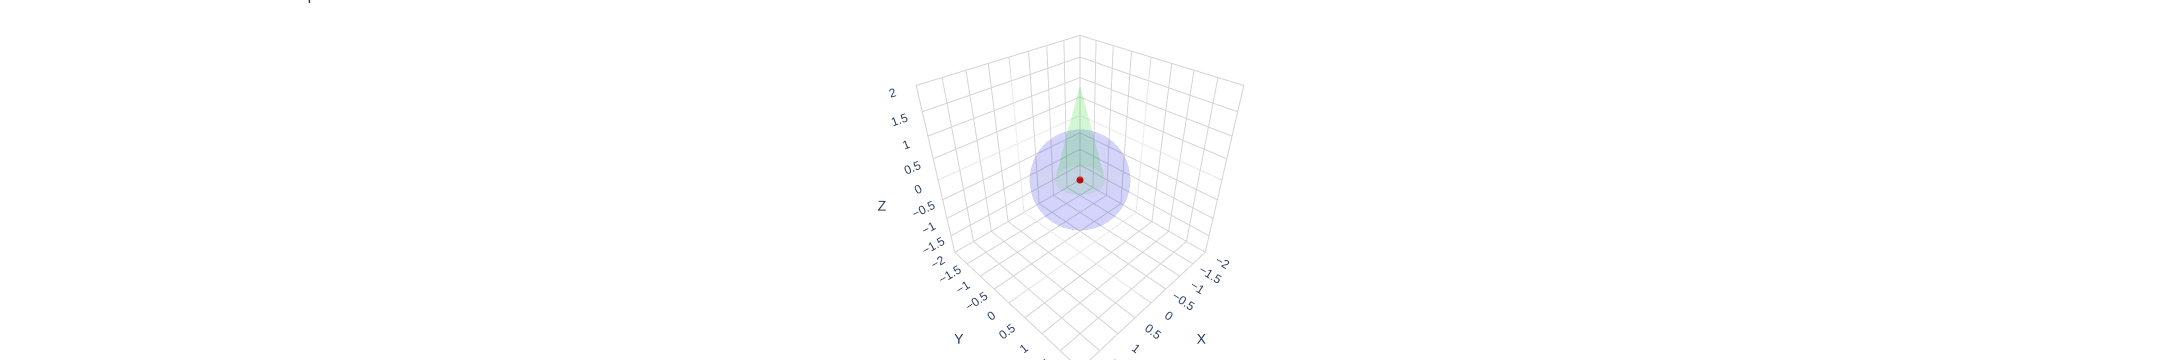

In [1]:
import numpy as np
import plotly.graph_objs as go
import plotly.io as pio
from ipywidgets import interact, FloatSlider, Button, HBox, VBox, Output
import tempfile, os, webbrowser

pio.renderers.default = "jupyterlab"

def create_sphere(center, radius, color='rgba(0,0,255,0.3)'):
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    x = center[0] + radius * np.cos(u) * np.sin(v)
    y = center[1] + radius * np.sin(u) * np.sin(v)
    z = center[2] + radius * np.cos(v)
    return go.Surface(
        x=x, y=y, z=z,
        opacity=0.3,
        colorscale=[[0, color], [1, color]],
        showscale=False,
        name='Sphere'
    )

def create_cone(base_center, height, radius, color='rgba(0,255,0,0.3)'):
    # Support negative height (cone points down)
    n_theta = 40
    n_z = 20
    theta = np.linspace(0, 2 * np.pi, n_theta)
    z = np.linspace(0, height, n_z)
    theta, z = np.meshgrid(theta, z)
    # The cone always starts at base_center and extends along z by height
    if height == 0:
        height = 1e-6  # avoid division by zero
    x = base_center[0] + (radius * (1 - z / height)) * np.cos(theta)
    y = base_center[1] + (radius * (1 - z / height)) * np.sin(theta)
    z = base_center[2] + z
    return go.Surface(
        x=x, y=y, z=z,
        opacity=0.3,
        colorscale=[[0, color], [1, color]],
        showscale=False,
        name='Cone'
    )

def create_center_sphere(center, radius=0.05, color='red'):
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = center[0] + radius * np.cos(u) * np.sin(v)
    y = center[1] + radius * np.sin(u) * np.sin(v)
    z = center[2] + radius * np.cos(v)
    return go.Surface(
        x=x, y=y, z=z,
        opacity=1.0,
        colorscale=[[0, color], [1, color]],
        showscale=False,
        name='Center'
    )

def plot_figure(
    sphere_x=0, sphere_y=0, sphere_z=0, sphere_r=1.0,
    cone_x=0, cone_y=0, cone_z=0, cone_h=2.0, cone_r=0.5
):
    fig = go.Figure()
    fig.add_trace(create_sphere([sphere_x, sphere_y, sphere_z], sphere_r))
    fig.add_trace(create_cone([cone_x, cone_y, cone_z], cone_h, cone_r))
    fig.add_trace(create_center_sphere([sphere_x, sphere_y, sphere_z], radius=0.07))
    fig.update_layout(
        scene=dict(
            xaxis=dict(nticks=10, range=[-2, 2], backgroundcolor="white", gridcolor="lightgray", showbackground=True, title='X'),
            yaxis=dict(nticks=10, range=[-2, 2], backgroundcolor="white", gridcolor="lightgray", showbackground=True, title='Y'),
            zaxis=dict(nticks=10, range=[-2, 2], backgroundcolor="white", gridcolor="lightgray", showbackground=True, title='Z'),
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Cone and Sphere"
    )
    return fig

# Output widget for plot
out = Output()

# Store current parameters for export
params = {
    'sphere_x': 0, 'sphere_y': 0, 'sphere_z': 0, 'sphere_r': 1.0,
    'cone_x': 0, 'cone_y': 0, 'cone_z': 0, 'cone_h': 2.0, 'cone_r': 0.5
}

def update_plot(
    sphere_x, sphere_y, sphere_z, sphere_r,
    cone_x, cone_y, cone_z, cone_h, cone_r
):
    params.update(locals())
    fig = plot_figure(**params)
    with out:
        out.clear_output(wait=True)
        fig.show()

def open_in_new_tab(b):
    fig = plot_figure(**params)
    tmp = tempfile.NamedTemporaryFile(suffix='.html', delete=False)
    pio.write_html(fig, file=tmp.name, auto_open=False)
    webbrowser.open_new_tab('file://' + os.path.realpath(tmp.name))

button = Button(description="Open in New Tab")
button.on_click(open_in_new_tab)

# Sliders
sliders = {
    'sphere_x': FloatSlider(min=-1.5, max=1.5, step=0.05, value=0, description='Sphere X'),
    'sphere_y': FloatSlider(min=-1.5, max=1.5, step=0.05, value=0, description='Sphere Y'),
    'sphere_z': FloatSlider(min=-1.5, max=1.5, step=0.05, value=0, description='Sphere Z'),
    'sphere_r': FloatSlider(min=0.1, max=1.5, step=0.05, value=1.0, description='Sphere R'),
    'cone_x': FloatSlider(min=-1.5, max=1.5, step=0.05, value=0, description='Cone X'),
    'cone_y': FloatSlider(min=-1.5, max=1.5, step=0.05, value=0, description='Cone Y'),
    'cone_z': FloatSlider(min=-1.5, max=1.5, step=0.05, value=0, description='Cone Z'),
    'cone_h': FloatSlider(min=-2.0, max=2.0, step=0.05, value=2.0, description='Cone H'),
    'cone_r': FloatSlider(min=0.05, max=1.5, step=0.05, value=0.5, description='Cone R'),
}

ui = VBox([HBox(list(sliders.values())), button, out])

# Use interactive to link sliders to update_plot
from ipywidgets import interactive
interactive_plot = interactive(
    update_plot,
    **sliders
)
display(ui)
interactive_plot.update()